# Fraud Detection in transactions (Financial Data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
creditcard_df = pd.read_csv("../data/raw/creditcard.csv")

In [3]:
creditcard_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
creditcard_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Class Distribution

In [6]:
class_imbalance = creditcard_df["Class"].value_counts(normalize=True).mul(100).reset_index().assign(color = lambda x:np.where(x["Class"].eq(1),"#280B66","#808080"))
class_imbalance["Class"] = class_imbalance["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

As you can see the distribution of the target variable (Class) reveals a severe class imbalance in the dataset.

In [7]:
print("Precentage of each class in the dataset:")
class_imbalance

Precentage of each class in the dataset:


,Class,proportion,color
0,Legitimate,99.827251,#808080
1,Fraud,0.172749,#280B66


**Important note**: The x-axis in the zoomed figure has been restricted to improve the visibility of the minority (fraud) class. This visualization is provided solely to facilitate comparison between the two classes and does not alter the underlying class proportions. The actual distribution remains **approximately 99.83% legitimate transactions and 0.17% fraudulent transactions.**

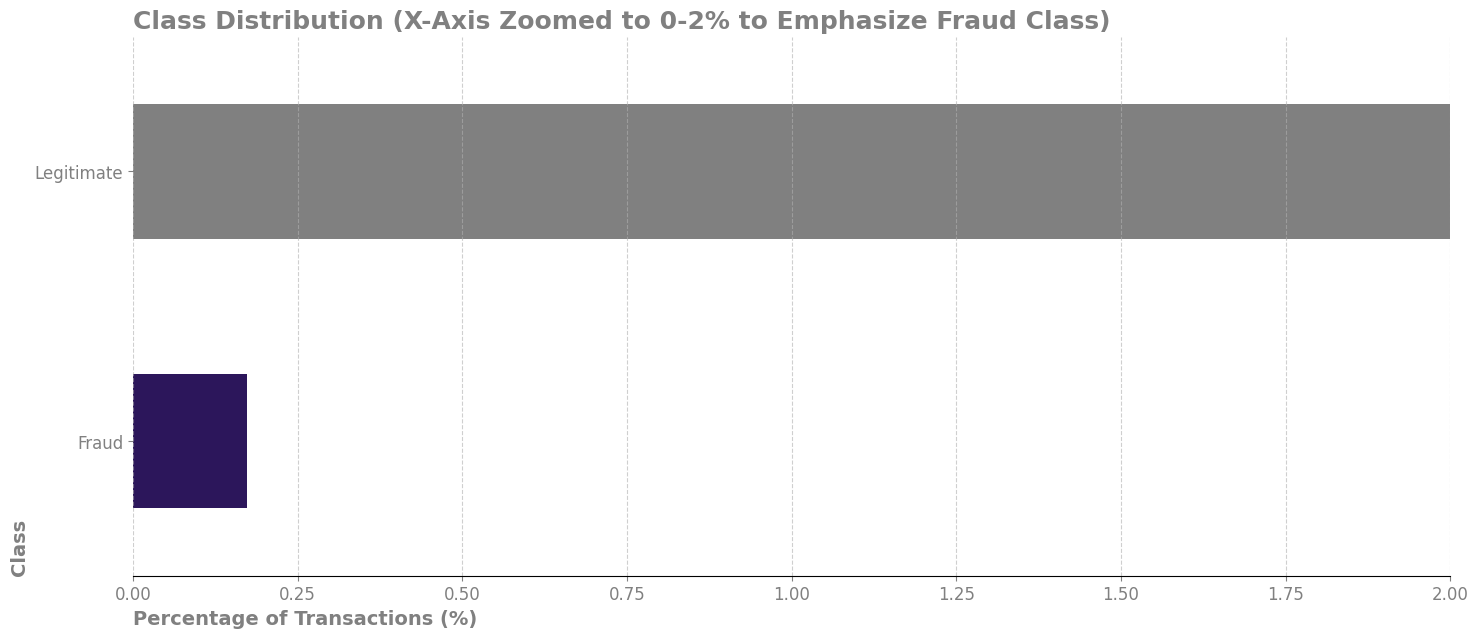

In [8]:
fig, ax = plt.subplots(figsize = (17,7))
sns.barplot(data=class_imbalance,
            x = "proportion",
            y = "Class",
            palette= list(class_imbalance["color"]),
            hue="Class",
            width=0.5,
            ax=ax)
ax.set_xlim(0, 2)
ax.spines[["right", "left", "top"]].set_visible(False)

ax.set_title(
    "Class Distribution (X-Axis Zoomed to 0-2% to Emphasize Fraud Class)",
    fontsize=18,
    fontweight="bold",
    color="gray",
    loc="left"
)

# Axis labels
ax.set_xlabel(
    "Percentage of Transactions (%)",
    fontsize=14,
    fontweight="bold",
    color="gray",
    loc="left"
)

ax.set_ylabel(
    "Class",
    fontsize=14,
    fontweight="bold",
    color="gray",
    loc="bottom"
)

ax.tick_params(axis="x", colors="gray", labelsize=12)
ax.tick_params(axis="y", colors="gray", labelsize=12)

ax.grid(axis="x", linestyle="dashed", alpha=0.6)
plt.savefig("../reports/figures/EDA_class_distribution.png", dpi = 300)